# Task - 1:

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
train_df = '/content/drive/MyDrive/Artificial-Intelligence-And-Machine-Learning-Materials/Week 5/FruitinAmazon/train'
test_df = '/content/drive/MyDrive/Artificial-Intelligence-And-Machine-Learning-Materials/Week 5/FruitinAmazon/test'

In [5]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing import image_dataset_from_directory

In [6]:
import os
class_names = sorted(os.listdir(train_df))

if not class_names:
    print("No class directories found in the train")
else:
    print(f"Found {len(class_names)} \nclasses: {class_names}")

Found 6 
classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [7]:
from PIL import Image, UnidentifiedImageError
corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(train_df, class_name)
    if os.path.isdir(class_path):
        images = os.listdir(class_path)
        for img_name in images:
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except (IOError, UnidentifiedImageError):
                corrupted_images.append(img_path)

if corrupted_images:
    print("\nCorrupted Images Found:")
    for img in corrupted_images:
        print(img)
else:
    print("\nNo corrupted images found.")



No corrupted images found.


In [8]:
class_counts = {}

for class_name in class_names:
    class_path = os.path.join(train_df, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        class_counts[class_name] = len(images)

print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print("=" * 45)
for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>15}")
print("=" * 45)


Class Distribution:
Class Name               Valid Image Count
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15


In [9]:
selected_images = []
selected_labels = []

for class_name in class_names:
    class_path = os.path.join(train_df, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if images:
            selected_img = os.path.join(class_path, random.choice(images))
            selected_images.append(selected_img)
            selected_labels.append(class_name)

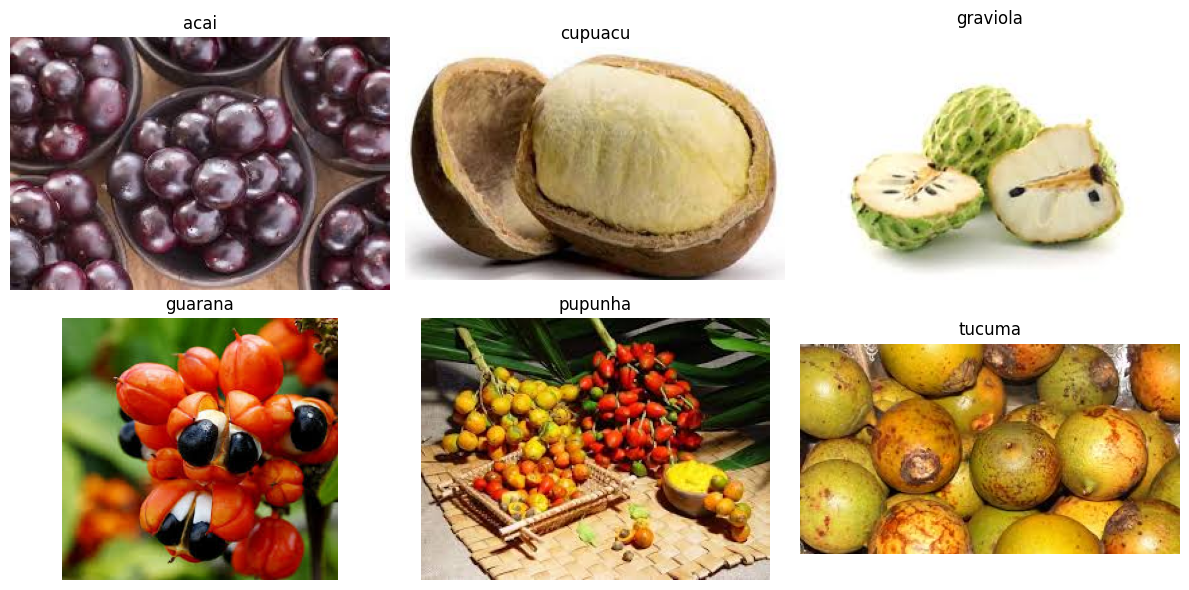

In [10]:
import matplotlib.image as mpimg

num_classes = len(selected_images)
cols = (num_classes + 1) // 2
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    if i < num_classes:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i])
        ax.axis("off")
    else:
        ax.axis("off")

plt.tight_layout()
plt.show()

In [11]:
def load_datasets(dataset_path, img_size=(128, 128), batch_size=32):
    train_ds = image_dataset_from_directory(
        dataset_path,
        validation_split=0.2,
        subset="training",
        seed=42,
        image_size=img_size,
        batch_size=batch_size
    )
    val_ds = image_dataset_from_directory(
        dataset_path,
        validation_split=0.2,
        subset="validation",
        seed=42,
        image_size=img_size,
        batch_size=batch_size
    )
    return train_ds, val_ds

train_ds, val_ds = load_datasets(train_df)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [12]:
def build_cnn_model(input_shape, num_classes):
    cnn_model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return cnn_model

input_shape = (128, 128, 3)
class_names = train_ds.class_names
cnn_model = build_cnn_model(input_shape, len(class_names))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
def compile_model(model):
    cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return cnn_model

cnn_model = compile_model(cnn_model)
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
def train_model(model, train_ds, val_ds, epochs=250, batch_size=16):
    callbacks = [
        keras.callbacks.ModelCheckpoint("best_model.h5", save_best_only=True),
        keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
    ]
    cnn_model.fit(train_ds, validation_data=val_ds, epochs=epochs, batch_size=batch_size, callbacks=callbacks)
    return cnn_model

# Example usage:
cnn_model = train_model(cnn_model, train_ds, val_ds)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.1047 - loss: 150.9155

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 640ms/step - accuracy: 0.1111 - loss: 207.3015 - val_accuracy: 0.1667 - val_loss: 300.5271
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.2245 - loss: 248.5562

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 343ms/step - accuracy: 0.2361 - loss: 211.2399 - val_accuracy: 0.3333 - val_loss: 84.1006
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.2668 - loss: 73.9818

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 308ms/step - accuracy: 0.2222 - loss: 76.8041 - val_accuracy: 0.0556 - val_loss: 35.6065
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.2841 - loss: 25.5609

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 313ms/step - accuracy: 0.3056 - loss: 22.0339 - val_accuracy: 0.4444 - val_loss: 14.0655
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.2697 - loss: 12.4122

...

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 287ms/step - accuracy: 0.4583 - loss: 3.3729 - val_accuracy: 0.2222 - val_loss: 4.3617
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.5422 - loss: 1.9956

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 385ms/step - accuracy: 0.4861 - loss: 2.0886 - val_accuracy: 0.2778 - val_loss: 3.0980
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.7240 - loss: 0.6793

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 287ms/step - accuracy: 0.7500 - loss: 0.6802 - val_accuracy: 0.4444 - val_loss: 2.5372
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 395ms/step - accuracy: 0.8750 - loss: 0.5296 - val_accuracy: 0.2778 - val_loss: 2.6654
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 419ms/step - accuracy: 0.8889 - loss: 0.5179 - val_accuracy: 0.2778 - val_loss: 2.5504
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.9294 - loss: 0.5206

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 352ms/step - accuracy: 0.9444 - loss: 0.4425 - val_accuracy: 0.3333 - val_loss: 2.4357
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.9346 - loss: 0.3164

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 303ms/step - accuracy: 0.9444 - loss: 0.3442 - val_accuracy: 0.3889 - val_loss: 2.3766
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 257ms/step - accuracy: 0.9306 - loss: 0.2851 - val_accuracy: 0.4444 - val_loss: 2.4934
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 252ms/step - accuracy: 0.9583 - loss: 0.1793 - val_accuracy: 0.3889 - val_loss: 2.7598
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 261ms/step - accuracy: 1.0000 - loss: 0.0921 - val_accuracy: 0.4444 - val_loss: 2.9608
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 268ms/step - accuracy: 0.9861 - loss: 0.0613 - val_accuracy: 0.4444 - val_loss: 2.7342
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 283ms/step - accuracy: 1.0000 - loss: 0.0355 - val_accuracy: 0.3333 - val_loss: 2.6059
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 520ms/step - accuracy: 1.0000 - loss: 0.0205 - val_accuracy: 0.5000 - val_loss: 2.7045
Epoch 19/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 287ms/step - accuracy: 1.0000 - loss: 0.0163 - val_accuracy: 0.4444 - val_lo

In [15]:
def evaluate_model(model, test_ds):
    test_loss, test_acc = model.evaluate(test_ds)
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Test Loss: {test_loss:.4f}")

evaluate_model(cnn_model, val_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.3889 - loss: 2.3766
Test Accuracy: 0.3889
Test Loss: 2.3766


In [16]:
def save_model(model, filename="model.h5"):
    model.save(filename)

def load_model(filename="model.h5"):
    return keras.models.load_model(filename)

save_model(cnn_model)
cnn_model = load_model()

In [17]:
from sklearn.metrics import classification_report

In [18]:
def make_predictions(model, test_ds, class_names):
    y_true, y_pred = [], []

    for images, labels in test_ds:
        predictions = model.predict(images)
        y_pred.extend(np.argmax(predictions, axis=1))
        y_true.extend(labels.numpy())

    print(classification_report(y_true, y_pred, target_names=class_names))

make_predictions(cnn_model, val_ds, class_names)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         3
     cupuacu       0.80      1.00      0.89         4
    graviola       0.33      1.00      0.50         1
     guarana       0.20      0.33      0.25         3
     pupunha       0.00      0.00      0.00         4
      tucuma       0.33      0.33      0.33         3

    accuracy                           0.39        18
   macro avg       0.28      0.44      0.33        18
weighted avg       0.29      0.39      0.32        18



In [19]:
from tensorflow.keras import layers, Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Dropout, BatchNormalization,
                                     Activation, Flatten, Dense)
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [20]:
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
]

def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

In [21]:
model = Sequential([
    layers.Lambda(data_augmentation, input_shape=(128, 128, 3)),

    layers.Rescaling(1./255),

    Conv2D(32, (3, 3), padding='same', use_bias=False),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), padding='same', use_bias=False),
    BatchNormalization(),
    Activation('relu'),
    Conv2D(64, (3, 3), padding='same', use_bias=False),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(128, (3, 3), padding='same', use_bias=False),
    BatchNormalization(),
    Activation('relu'),
    Conv2D(128, (3, 3), padding='same', use_bias=False),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(256, (3, 3), padding='same', use_bias=False),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(512, use_bias=False),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(256, use_bias=False),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # Output layer
    Dense(6, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [22]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    ModelCheckpoint("best_model.h5", save_best_only=True),
    EarlyStopping(patience=10, restore_best_weights=True)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks
)

test_loss, test_acc = model.evaluate(val_ds)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

from sklearn.metrics import classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1846 - loss: 2.6046

3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.1944 - loss: 2.5833 - val_accuracy: 0.2778 - val_loss: 1.7839
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.2778 - loss: 2.1140 - val_accuracy: 0.1667 - val_loss: 1.7874
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3247 - loss: 1.6554

3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.3333 - loss: 1.6637 - val_accuracy: 0.1667 - val_loss: 1.7767
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.4028 - loss: 1.4930 - val_accuracy: 0.1667 - val_loss: 1.8119
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step - accuracy: 0.5417 - loss: 1.3786 - val_accuracy: 0.1667 - val_loss: 1.8646
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.5278 - loss: 1.1480 - val_accuracy: 0.2222 - val_loss: 1.9379
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.5972 - loss: 1.1130 - val_accuracy: 0.2222 - val_loss: 2.0631
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.6250 - loss: 1.0870 - val_accuracy: 0.2222 - val_loss: 2.2219
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.6111 - loss: 0.9630 - val_accuracy: 0.2222 - val_loss: 2.3730
Epoch 10/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.5417 - loss: 1.1130 - val_accuracy: 0.2222 - val_loss: 2.4884
Epoch 11/50
3/3 ━━━━━

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Task - 2:

In [23]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

base_model = VGG16(weights='imagenet',
                  include_top=False,
                  input_shape=(128, 128, 3))


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [24]:
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(6, activation='softmax')(x)

In [25]:
model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adam(learning_rate=0.0001),
             loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])
callbacks = [
    ModelCheckpoint("best_vgg_model.h5", save_best_only=True),
    EarlyStopping(patience=5, restore_best_weights=True)
]

In [26]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks
)
test_loss, test_acc = model.evaluate(val_ds)
print(f"Transfer Learning Model Accuracy: {test_acc:.4f}")
print(f"Transfer Learning Model Loss: {test_loss:.4f}")

from sklearn.metrics import classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1898 - loss: 14.4823

3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 4s/step - accuracy: 0.1944 - loss: 14.5361 - val_accuracy: 0.2222 - val_loss: 4.0095
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2598 - loss: 11.3633

3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 4s/step - accuracy: 0.2639 - loss: 11.1553 - val_accuracy: 0.2778 - val_loss: 2.9748
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2743 - loss: 8.6362

3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - accuracy: 0.2917 - loss: 8.6413 - val_accuracy: 0.2222 - val_loss: 2.7993
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.2639 - loss: 8.1881 - val_accuracy: 0.2222 - val_loss: 2.8481
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2153 - loss: 9.0592

3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 4s/step - accuracy: 0.2083 - loss: 8.9244 - val_accuracy: 0.2222 - val_loss: 2.7024
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3507 - loss: 9.5985

3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 4s/step - accuracy: 0.3333 - loss: 9.3810 - val_accuracy: 0.4444 - val_loss: 2.3432
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3536 - loss: 6.1788

3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 4s/step - accuracy: 0.3889 - loss: 5.9843 - val_accuracy: 0.5556 - val_loss: 1.9807
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4155 - loss: 6.3176

3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 4s/step - accuracy: 0.4028 - loss: 6.1985 - val_accuracy: 0.6111 - val_loss: 1.6854
Epoch 9/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4514 - loss: 5.9955

3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 4s/step - accuracy: 0.4167 - loss: 6.5984 - val_accuracy: 0.6667 - val_loss: 1.4892
Epoch 10/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4051 - loss: 6.2293

3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 5s/step - accuracy: 0.4028 - loss: 5.9819 - val_accuracy: 0.6111 - val_loss: 1.4721
Epoch 11/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 4s/step - accuracy: 0.4861 - loss: 5.9966 - val_accuracy: 0.5000 - val_loss: 1.5366
Epoch 12/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.4028 - loss: 5.0287 - val_accuracy: 0.5556 - val_loss: 1.5429
Epoch 13/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 4s/step - accuracy: 0.5000 - loss: 4.0600 - val_accuracy: 0.6111 - val_loss: 1.5530
Epoch 14/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 4s/step - accuracy: 0.4583 - loss: 5.2308 - val_accuracy: 0.6111 - val_loss: 1.5676
Epoch 15/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.4861 - loss: 4.4160 - val_accuracy: 0.6667 - val_loss: 1.5951
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.6111 - loss: 1.4721
Transfer Learning Model Accuracy: 0.6111
Transfer Learning Model Loss: 1.4721

Classification Report:
              precision    recall  f1-score   support

        acai       0.00      0.00  

In [27]:
from sklearn.metrics import classification_report

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_df,
    image_size=(128, 128),  # Original image size
    batch_size=32,
    validation_split=0.2,
    subset='training',
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_df,
    image_size=(128, 128),
    batch_size=32,
    validation_split=0.2,
    subset='validation',
    seed=42
)

class_names = train_ds.class_names
num_classes = len(class_names)

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

# Build Transfer Learning Model
inputs = keras.Input(shape=(128, 128, 3))
x = data_augmentation(inputs)
x = layers.Rescaling(1./255)(x)
x = layers.Resizing(224, 224)(x)

# Load VGG16
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False  #freeze base model

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# train model
callbacks = [
    ModelCheckpoint("best_vgg_model.h5", save_best_only=True),
    EarlyStopping(patience=5, restore_best_weights=True)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks
)

# evaluate the Model
test_loss, test_acc = model.evaluate(val_ds)
print(f"\nTransfer Learning Model Accuracy: {test_acc:.4f}")
print(f"Transfer Learning Model Loss: {test_loss:.4f}")

# Classification Report
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,980,422 (57.15 MB)

 Trainable params: 265,734 (1.01 MB)

...

3/3 ━━━━━━━━━━━━━━━━━━━━ 41s 13s/step - accuracy: 0.3750 - loss: 1.5252 - val_accuracy: 0.5000 - val_loss: 1.6570
Epoch 28/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.3501 - loss: 1.5363  

3/3 ━━━━━━━━━━━━━━━━━━━━ 39s 13s/step - accuracy: 0.3472 - loss: 1.5412 - val_accuracy: 0.5000 - val_loss: 1.6559
Epoch 29/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.2899 - loss: 1.6795  

3/3 ━━━━━━━━━━━━━━━━━━━━ 39s 13s/step - accuracy: 0.2917 - loss: 1.6767 - val_accuracy: 0.5000 - val_loss: 1.6550
Epoch 30/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.4155 - loss: 1.4779  

3/3 ━━━━━━━━━━━━━━━━━━━━ 41s 13s/step - accuracy: 0.4028 - loss: 1.5250 - val_accuracy: 0.5000 - val_loss: 1.6521
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 0.5000 - loss: 1.6521

Transfer Learning Model Accuracy: 0.5000
Transfer Learning Model Loss: 1.6521

Classification Report:
              precision    recall  f1-score   support

        acai       1.00      0.33      0.50         3
     cupuacu       0.80      1.00      0.89         4
    graviola       0.25      1.00      0.40         1
     guarana       0.40      0.67      0.50         3
     pupunha       0.00      0.00      0.00         4
      tucuma       0.33      0.33      0.33         3

    accuracy                           0.50        18
   macro avg       0.46      0.56      0.44        18
weighted avg       0.48      0.50      0.44        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
